Shape : (7043, 21)

Premières lignes :

Info colonnes :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null  

C:\Users\Admin\AppData\Local\Temp\ipykernel_13320\3964179664.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Churn", data=df, palette="Set2", ax=axes[0])


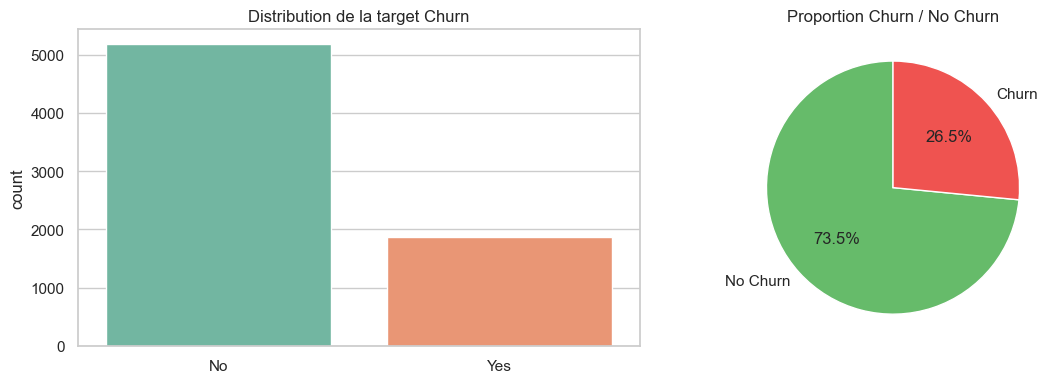

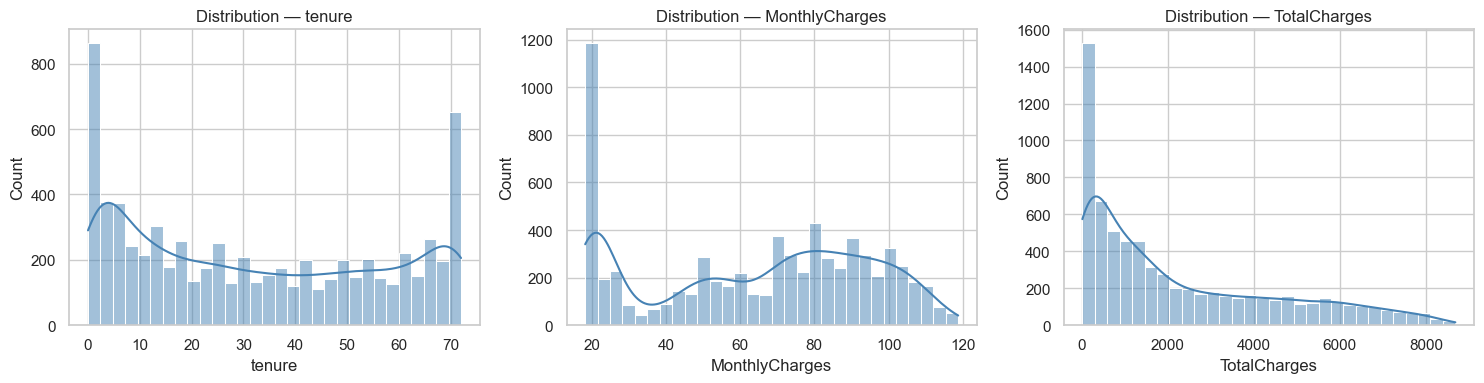

C:\Users\Admin\AppData\Local\Temp\ipykernel_13320\3964179664.py:115: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Churn", y=col, data=df, palette="Set2", ax=axes[i])
C:\Users\Admin\AppData\Local\Temp\ipykernel_13320\3964179664.py:115: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Churn", y=col, data=df, palette="Set2", ax=axes[i])
C:\Users\Admin\AppData\Local\Temp\ipykernel_13320\3964179664.py:115: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Churn", y=col, data=df, palette="Set2", ax=axes[i])


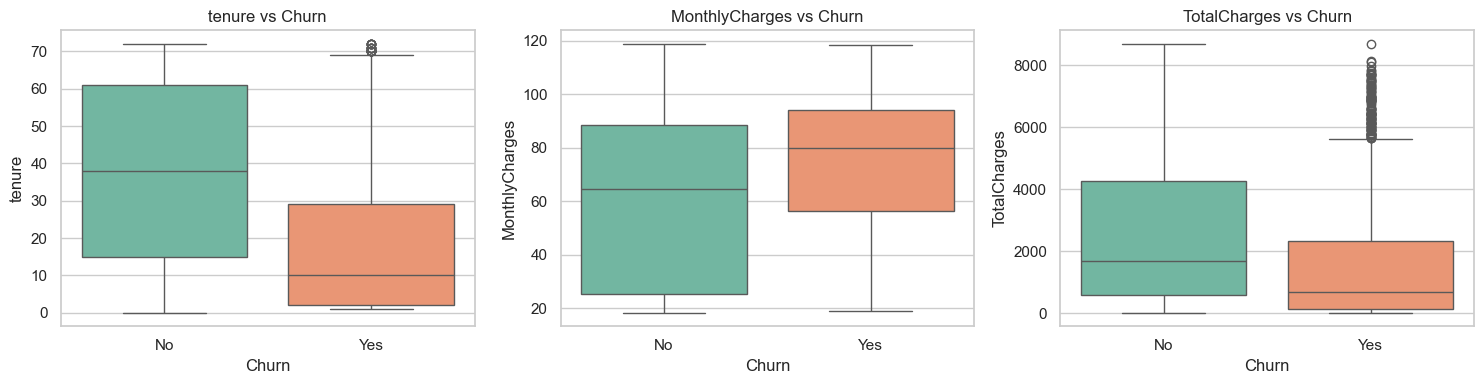


Moyennes par groupe Churn :
       tenure  MonthlyCharges  TotalCharges
Churn                                      
No      37.57           61.27       2555.34
Yes     17.98           74.44       1531.80


C:\Users\Admin\AppData\Local\Temp\ipykernel_13320\3964179664.py:151: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Admin\AppData\Local\Temp\ipykernel_13320\3964179664.py:151: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Admin\AppData\Local\Temp\ipykernel_13320\3964179664.py:151: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Admin\AppData\Local\Temp\ipykernel_13320\3964179664.py:151: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable t

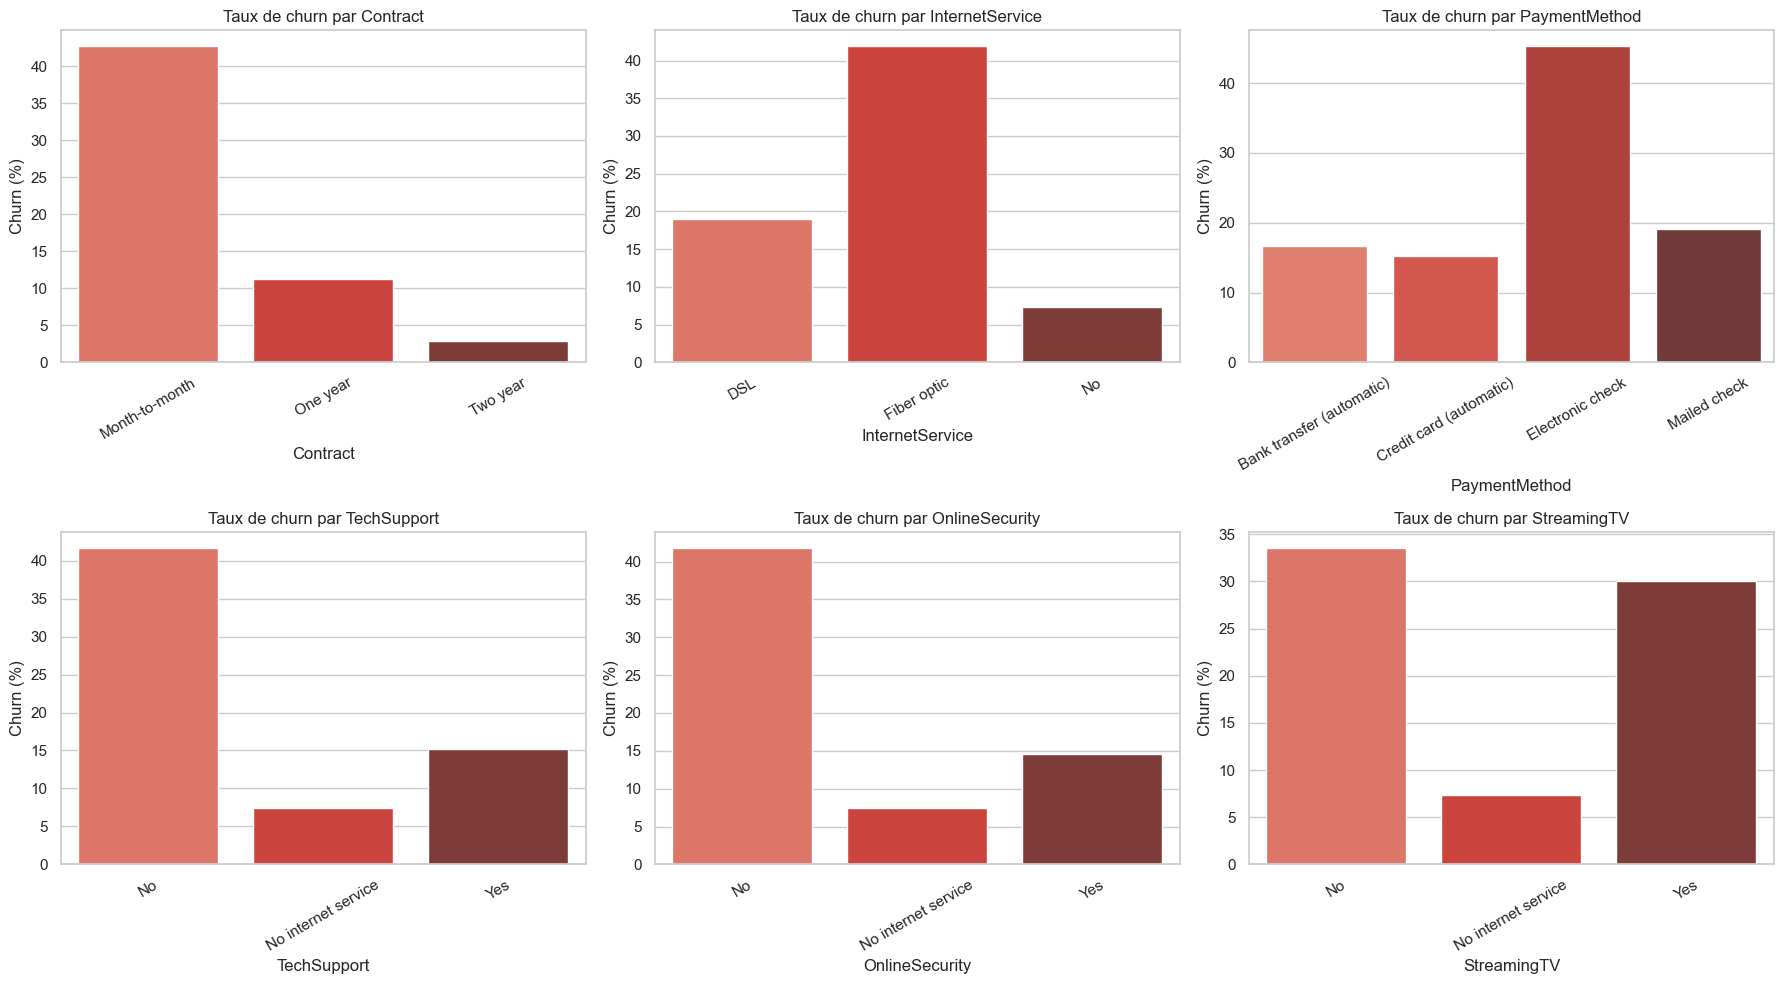

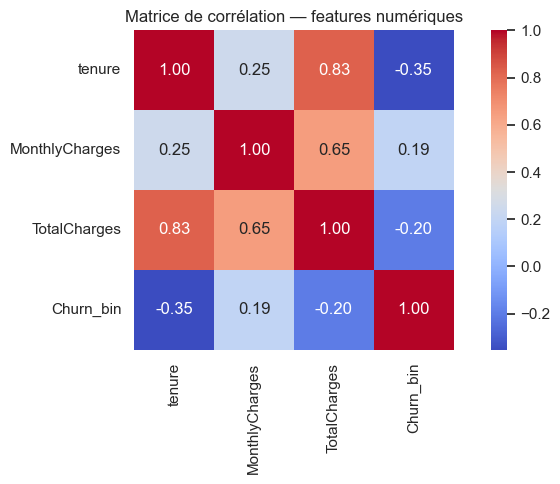


Corrélation avec Churn :
tenure           -0.352229
TotalCharges     -0.199484
MonthlyCharges    0.193356
Name: Churn_bin, dtype: float64


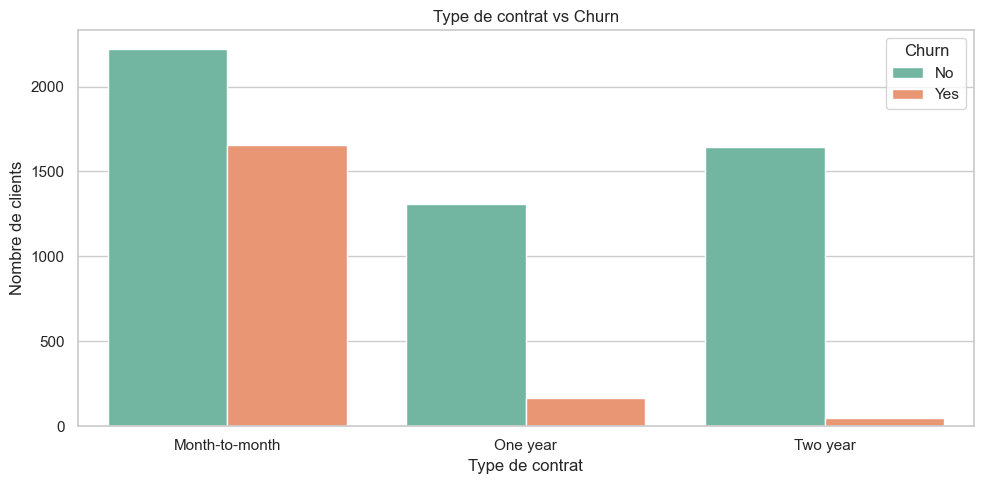


Taux de churn par type de contrat :
Contract
Month-to-month    42.7%
One year          11.3%
Two year           2.8%
Name: Churn, dtype: object


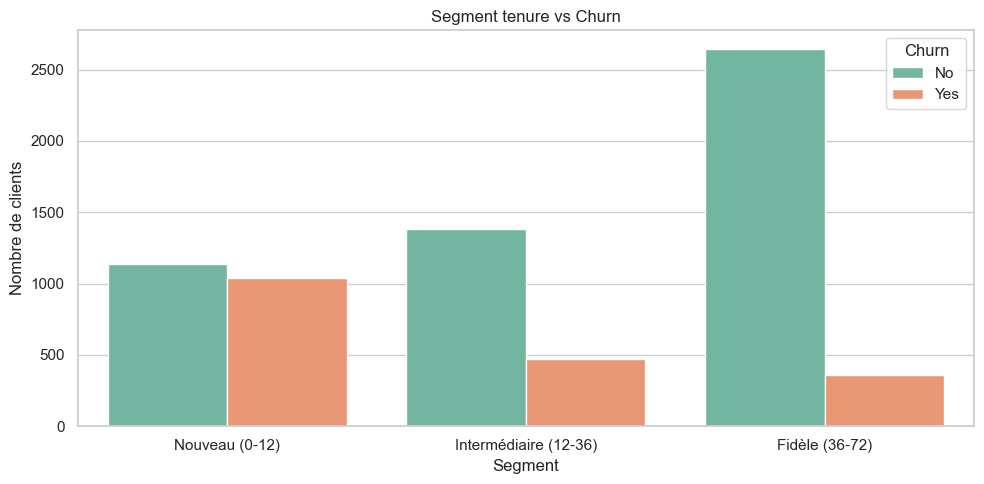


Taux de churn par segment tenure :
SegmentTenure
Nouveau (0-12)           47.7%
Intermédiaire (12-36)    25.5%
Fidèle (36-72)           11.9%
Name: Churn, dtype: object

INSIGHTS PRINCIPAUX — EDA

1. DÉSÉQUILIBRE : 26% churn → scale_pos_weight nécessaire

2. FEATURES CLÉS :
   - Contract       : Month-to-month churne à ~43%
   - tenure         : Nouveaux clients (<12 mois) à risque élevé
   - MonthlyCharges : Charges élevées corrélées au churn
   - InternetService: Fiber optic churne plus que DSL

3. PROFIL CLIENT À RISQUE :
   - Contrat month-to-month
   - Fiber optic sans TechSupport ni OnlineSecurity
   - Tenure < 12 mois
   - MonthlyCharges > 70

4. PROFIL CLIENT FIDÈLE :
   - Contrat 2 ans
   - Tenure > 36 mois
   - Plusieurs services souscrits



C:\Users\Admin\AppData\Local\Temp\ipykernel_13320\3964179664.py:247: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("SegmentTenure")["Churn"]


In [1]:
# notebooks/eda.ipynb
"""
Exploratory Data Analysis — Telecom Churn Prediction
-----------------------------------------------------
Analyse exploratoire complète du dataset Telco Customer Churn.

Sections :
    1. Chargement et aperçu général
    2. Valeurs manquantes et types
    3. Distribution de la target
    4. Features numériques
    5. Features catégorielles
    6. Corrélations
    7. Insights métier
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration visuelle
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.figsize"] = (10, 5)

# -------------------------
# 1. Chargement et aperçu
# -------------------------

df = pd.read_csv("../data/raw/churn.csv")

print("Shape :", df.shape)
print("\nPremières lignes :")
df.head()

# -------------------------
print("\nInfo colonnes :")
df.info()

# -------------------------
print("\nStatistiques descriptives :")
df.describe()


# -------------------------
# 2. Valeurs manquantes et types
# -------------------------

print("\nValeurs manquantes :")
print(df.isnull().sum())

# TotalCharges contient des espaces vides — cas particulier
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print(f"\nTotalCharges manquants après conversion : {df['TotalCharges'].isna().sum()}")

# Ces 11 clients ont tenure=0 — nouveaux clients sans historique de facturation
print(df[df["TotalCharges"].isna()][["tenure", "MonthlyCharges", "TotalCharges"]])


# -------------------------
# 3. Distribution de la target
# -------------------------

churn_counts = df["Churn"].value_counts()
churn_pct    = df["Churn"].value_counts(normalize=True) * 100

print("\nDistribution Churn :")
print(churn_counts)
print(f"\nTaux de churn : {churn_pct['Yes']:.1f}%")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Barplot
sns.countplot(x="Churn", data=df, palette="Set2", ax=axes[0])
axes[0].set_title("Distribution de la target Churn")
axes[0].set_xlabel("")

# Pie chart
axes[1].pie(
    churn_counts,
    labels=["No Churn", "Churn"],
    autopct="%1.1f%%",
    colors=["#66bb6a", "#ef5350"],
    startangle=90
)
axes[1].set_title("Proportion Churn / No Churn")

plt.tight_layout()
plt.show()

# -------------------------
# Insight : déséquilibre de classes ~26% churn
# → nécessite scale_pos_weight dans XGBoost


# -------------------------
# 4. Features numériques
# -------------------------

numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

# Distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col].dropna(), bins=30, kde=True, ax=axes[i], color="steelblue")
    axes[i].set_title(f"Distribution — {col}")
plt.tight_layout()
plt.show()

# Boxplots vs Churn
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(numeric_cols):
    sns.boxplot(x="Churn", y=col, data=df, palette="Set2", ax=axes[i])
    axes[i].set_title(f"{col} vs Churn")
plt.tight_layout()
plt.show()

# Statistiques par groupe
print("\nMoyennes par groupe Churn :")
print(df.groupby("Churn")[numeric_cols].mean().round(2))

# -------------------------
# Insights :
# - tenure faible → plus de churn (nouveaux clients instables)
# - MonthlyCharges élevé → plus de churn
# - TotalCharges faible chez les churners (corrélé à tenure)


# -------------------------
# 5. Features catégorielles
# -------------------------

cat_cols = [
    "Contract", "InternetService", "PaymentMethod",
    "TechSupport", "OnlineSecurity", "StreamingTV"
]

# Taux de churn par feature catégorielle
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_rate = (
        df.groupby(col)["Churn"]
        .apply(lambda x: (x == "Yes").mean() * 100)
        .reset_index()
        .rename(columns={"Churn": "ChurnRate"})
    )
    sns.barplot(
        data=churn_rate,
        x=col,
        y="ChurnRate",
        palette="Reds_d",
        ax=axes[i]
    )
    axes[i].set_title(f"Taux de churn par {col}")
    axes[i].set_ylabel("Churn (%)")
    axes[i].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

# -------------------------
# Insights :
# - Month-to-month → taux de churn très élevé (~43%)
# - Two year → taux de churn très faible (~3%)
# - Fiber optic → plus de churn que DSL
# - Sans TechSupport / OnlineSecurity → plus de churn


# -------------------------
# 6. Corrélations
# -------------------------

# Encoder target pour corrélation
df["Churn_bin"] = (df["Churn"] == "Yes").astype(int)

corr = df[["tenure", "MonthlyCharges", "TotalCharges", "Churn_bin"]].corr()

plt.figure(figsize=(8, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Matrice de corrélation — features numériques")
plt.tight_layout()
plt.show()

print("\nCorrélation avec Churn :")
print(corr["Churn_bin"].drop("Churn_bin").sort_values())

# -------------------------
# Insights :
# - tenure corrélé négativement avec churn (-0.35) → fidélité = rétention
# - MonthlyCharges corrélé positivement (+0.19) → charges élevées = risque
# - TotalCharges faiblement corrélé (effet tenure dominant)


# -------------------------
# 7. Analyse Contract — feature la plus importante
# -------------------------

plt.figure(figsize=(10, 5))
sns.countplot(
    x="Contract",
    hue="Churn",
    data=df,
    palette="Set2"
)
plt.title("Type de contrat vs Churn")
plt.xlabel("Type de contrat")
plt.ylabel("Nombre de clients")
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

print("\nTaux de churn par type de contrat :")
print(
    df.groupby("Contract")["Churn"]
    .apply(lambda x: f"{(x == 'Yes').mean()*100:.1f}%")
)


# -------------------------
# 8. Analyse tenure — segmentation
# -------------------------

# Segmenter tenure
bins   = [0, 12, 36, 72]
labels = ["Nouveau (0-12)", "Intermédiaire (12-36)", "Fidèle (36-72)"]
df["SegmentTenure"] = pd.cut(df["tenure"], bins=bins, labels=labels)

plt.figure(figsize=(10, 5))
sns.countplot(
    x="SegmentTenure",
    hue="Churn",
    data=df,
    palette="Set2"
)
plt.title("Segment tenure vs Churn")
plt.xlabel("Segment")
plt.ylabel("Nombre de clients")
plt.tight_layout()
plt.show()

print("\nTaux de churn par segment tenure :")
print(
    df.groupby("SegmentTenure")["Churn"]
    .apply(lambda x: f"{(x == 'Yes').mean()*100:.1f}%")
)


# -------------------------
# 9. Résumé des insights
# -------------------------

print("""
========================================
INSIGHTS PRINCIPAUX — EDA
========================================

1. DÉSÉQUILIBRE : 26% churn → scale_pos_weight nécessaire

2. FEATURES CLÉS :
   - Contract       : Month-to-month churne à ~43%
   - tenure         : Nouveaux clients (<12 mois) à risque élevé
   - MonthlyCharges : Charges élevées corrélées au churn
   - InternetService: Fiber optic churne plus que DSL

3. PROFIL CLIENT À RISQUE :
   - Contrat month-to-month
   - Fiber optic sans TechSupport ni OnlineSecurity
   - Tenure < 12 mois
   - MonthlyCharges > 70

4. PROFIL CLIENT FIDÈLE :
   - Contrat 2 ans
   - Tenure > 36 mois
   - Plusieurs services souscrits
========================================
""")